# 11-Background Batch Processing

In the previous lessons, we engineered endpoints for high-speed inference. We optimized the server to return results in milliseconds.

But what if your client is not asking for a single sentence classification? What if they upload a **2-hour 4K video** for frame-by-frame object detection, or submit a batch of **10,000 text documents** for embedding generation?

These operations might require $T_{inference} = 45 \text{ minutes}$.

If you attempt to process this inside a standard REST endpoint, the system will catastrophically fail. Standard HTTP connections (and load balancers like Nginx or AWS ELB) have strict **Timeouts** (typically $30$ to $60$ seconds). If your server does not return a JSON response within 60 seconds, the load balancer violently severs the connection. The user sees a `504 Gateway Timeout` error, but your GPU keeps blindly crunching the 45-minute video for a user who is no longer there, wasting massive compute resources.

To survive massive workloads, we must dismantle the synchronous Request/Response cycle and master the architecture of **Asynchronous Task Queues**.

Let's set up our FastAPI environment to engineer the "Ticket Polling" architecture.

In [4]:
import torch
import time
import uuid
import asyncio
from fastapi import FastAPI, BackgroundTasks, HTTPException
from pydantic import BaseModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch, FastAPI, and Background Task Environment Ready.")

✅ PyTorch, FastAPI, and Background Task Environment Ready.


# 1. The Physics of the 202 Accepted Pattern

To prevent HTTP timeouts, we must separate the *acknowledgment* of the request from the *execution* of the request.

We implement the **HTTP 202 Accepted** paradigm:

1. **The Submission**: The client sends the massive 10,000-document JSON payload.
2. **The Handoff**: The API receives it, instantly generates a unique cryptographic ID (e.g., `task_id = "abc-123"`), hands the payload to a background worker, and returns `HTTP 202 Accepted` along with the `task_id` in less than $0.1$ seconds. The HTTP connection is safely closed.
3. **The Background Execution**: The GPU grinds through the 10,000 documents over 45 minutes, updating the status of `task_id` in a database (e.g., `Pending` $\rightarrow$ `Processing` $\rightarrow$ `Completed`).
4. **The Polling**: The client occasionally sends a lightweight `GET` request to a `/status/{task_id}` route to check on their job. Once the status is `Completed`, they download the final result.

# 2. FastAPI `BackgroundTasks`

For Enterprise systems distributed across multiple servers, this pattern is typically handled using heavy external message brokers like **Celery, Redis, and RabbitMQ**.

However, FastAPI provides a native, incredibly elegant mechanism for single-server orchestration called `BackgroundTasks`.
When you declare a `BackgroundTasks` parameter in your route, FastAPI automatically intercepts the function you pass to it. It holds the function in memory, completely finishes sending the HTTP response to the user, closes the network socket, and *then* quietly executes the function in a separate thread.

# 3. Architecting the Task Queue API

Let's build a production-ready asynchronous batch processing API. We will simulate a heavy ML video processing workload, engineer the submission route, the background worker, and the status polling route.

*(Note: In a real environment, `JOB_DATABASE` would be a persistent Redis cache or PostgreSQL database. For this notebook, we use a global Python dictionary).*

In [5]:
# --- ⚙️ main.py ---
app = FastAPI(title="Enterprise Batch Processing API")

# 1. The State Database
# Stores the status and results of long-running GPU jobs. O(1) lookup.
JOB_DATABASE = {}

# 2. Architect the Data Schemas
class BatchRequest(BaseModel):
    video_url: str
    target_fps: int = 30

class JobSubmissionResponse(BaseModel):
    task_id: str
    message: str

class JobStatusResponse(BaseModel):
    task_id: str
    status: str
    progress: float
    result: dict | None = None

# 3. The Heavy GPU Worker Function
def execute_heavy_video_processing(task_id: str, video_url: str):
    """
    This function runs strictly in the background AFTER the HTTP response is sent.
    It simulates a 10-second heavy GPU workload, updating the database as it goes.
    """
    try:
        # Phase 1: Initialization
        JOB_DATABASE[task_id] = {"status": "Processing", "progress": 0.0, "result": None}
        print(f"[WORKER] Task {task_id} started: Downloading {video_url}...")
        
        # Simulate heavy mathematical processing (e.g., Frame-by-Frame CNN execution)
        total_frames = 100
        for frame in range(1, total_frames + 1):
            time.sleep(0.1)  # Simulating 100ms per frame of GPU time
            
            # Periodically update the database so the client can track progress!
            if frame % 20 == 0:
                progress = (frame / total_frames) * 100
                JOB_DATABASE[task_id]["progress"] = progress
                print(f"[WORKER] Task {task_id} Progress: {progress}%")
                
        # Phase 2: Finalization
        JOB_DATABASE[task_id]["status"] = "Completed"
        JOB_DATABASE[task_id]["result"] = {
            "objects_detected": 402,
            "bounding_boxes_generated": True,
            "compute_time_seconds": 10.0
        }
        print(f"[WORKER] Task {task_id} Completed successfully.")
        
    except Exception as e:
        JOB_DATABASE[task_id]["status"] = "Failed"
        JOB_DATABASE[task_id]["result"] = {"error": str(e)}
        print(f"[WORKER] Task {task_id} FAILED: {str(e)}")

# 4. The Submission Route (HTTP POST)
@app.post("/v1/jobs/submit", response_model=JobSubmissionResponse, status_code=202)
async def submit_batch_job(request: BatchRequest, background_tasks: BackgroundTasks):
    # A. Generate a mathematically unique Task ID
    task_id = str(uuid.uuid4())
    
    # B. Initialize the job in the database
    JOB_DATABASE[task_id] = {"status": "Pending", "progress": 0.0, "result": None}
    
    # C. Hand the heavy function to the FastAPI Background Task orchestrator
    # Notice we do NOT use 'await' here. We just pass the function pointer and arguments.
    background_tasks.add_task(execute_heavy_video_processing, task_id, request.video_url)
    
    # D. Return instantly to the client before the GPU even starts!
    return JobSubmissionResponse(
        task_id=task_id,
        message="Job successfully queued. Use the task_id to poll for status."
    )

# 5. The Polling Route (HTTP GET)
@app.get("/v1/jobs/status/{task_id}", response_model=JobStatusResponse)
async def check_job_status(task_id: str):
    # Retrieve the current state from the database
    job_data = JOB_DATABASE.get(task_id)
    
    if not job_data:
        raise HTTPException(status_code=404, detail="Task ID not found.")
        
    return JobStatusResponse(
        task_id=task_id,
        status=job_data["status"],
        progress=job_data["progress"],
        result=job_data["result"]
    )

print("Success! Background Orchestration Architecture compiled.")

Success! Background Orchestration Architecture compiled.


# 4. Visualizing the Orchestration Physics

To scientifically prove why this architecture prevents network collapse, we will plot a Gantt chart comparing a **Standard Blocking HTTP Request** against the **Ticket Polling Architecture**.

We will assume a standard Load Balancer timeout of 5.0 seconds, and a GPU workload that takes 10.0 seconds.

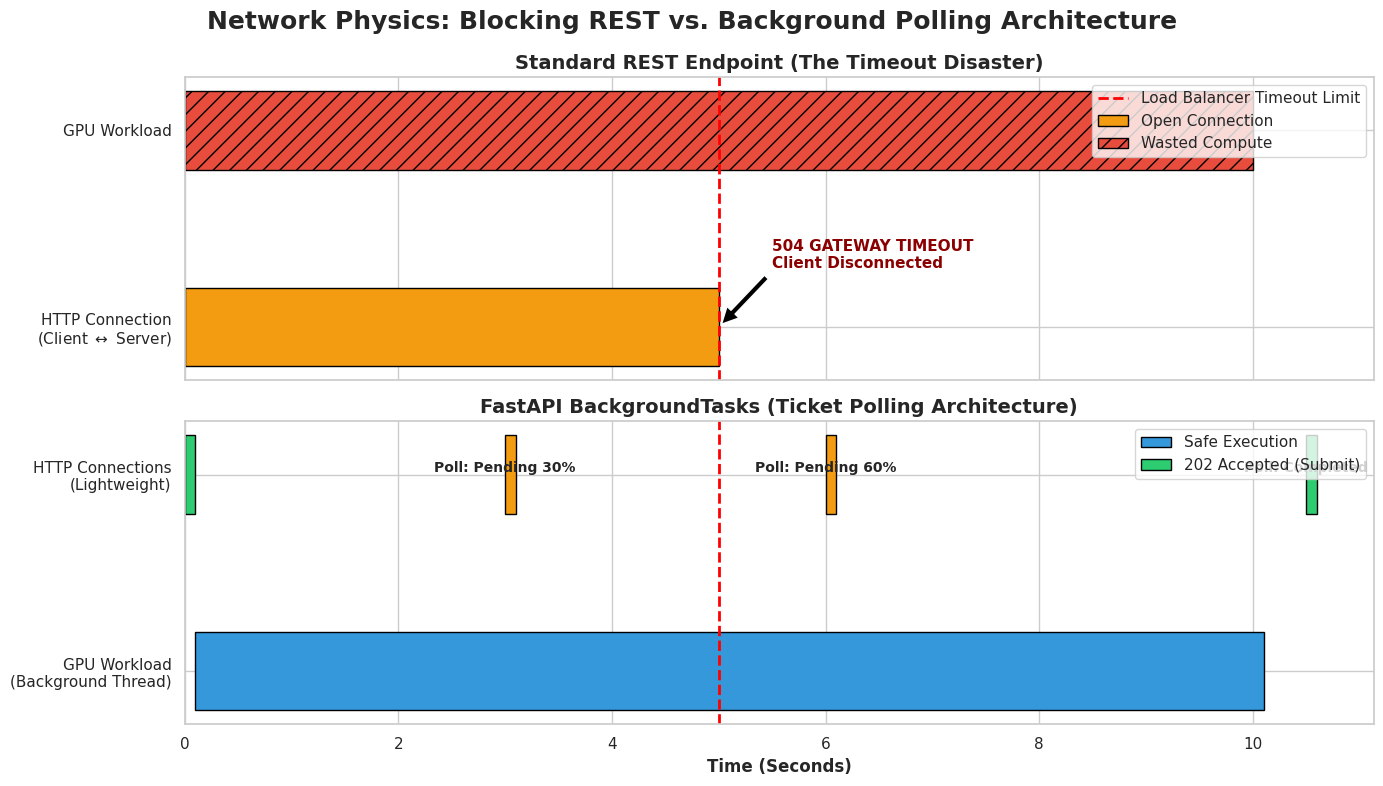


--- 💡 Engineering Insight ---
Look at the Top Graph. The client opens an HTTP connection and waits. At 5.0 seconds, the cloud infrastructure forcefully cuts the cord. The client gets an error, but the GPU has no idea the client is gone! It grinds for 5 more seconds, generates a result, tries to return it, and crashes because the network socket is closed.
Look at the Bottom Graph. The HTTP connection is open for less than 0.1 seconds (The Green blocks). The client gets a tracking ticket and safely disconnects. The GPU safely executes on a background thread entirely decoupled from the network. When the client periodically checks in (Polling), the server answers in milliseconds. The Load Balancer timeout limit is never even approached!


In [6]:
# 1. Define the Architectural Timelines
lb_timeout = 5.0  # Load Balancer kills connection at 5 seconds
gpu_time = 10.0   # Total computation time

# Scenario A: Blocking REST Request
block_start = 0.0
block_timeout = 5.0
block_gpu_end = 10.0

# Scenario B: Background Task + Polling
poll_submit_start, poll_submit_end = 0.0, 0.1
gpu_bg_start, gpu_bg_end = 0.1, 10.1
# Client polls at 3s, 6s, and 10.5s
polls = [(3.0, 3.1, "Pending 30%"), (6.0, 6.1, "Pending 60%"), (10.5, 10.6, "Completed")]

# 2. Render the Orchestration Physics
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Network Physics: Blocking REST vs. Background Polling Architecture", fontsize=18, fontweight='bold')

# --- Plot A: The Timeout Disaster ---
ax1 = axes[0]
# The HTTP Connection (Dies at 5.0s)
ax1.barh(y="HTTP Connection\n(Client $\\leftrightarrow$ Server)", width=block_timeout, left=block_start, 
         color="#f39c12", edgecolor="black", height=0.4, label="Open Connection")
ax1.annotate('504 GATEWAY TIMEOUT\nClient Disconnected', xy=(block_timeout, 0), xytext=(block_timeout + 0.5, 0.3),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11, fontweight='bold', color='darkred')

# The GPU Workload (Keeps running uselessly)
ax1.barh(y="GPU Workload", width=block_gpu_end, left=block_start, 
         color="#e74c3c", edgecolor="black", height=0.4, hatch="//", label="Wasted Compute")

ax1.set_title("Standard REST Endpoint (The Timeout Disaster)", fontweight='bold', fontsize=14)
ax1.axvline(x=lb_timeout, color='red', linestyle='--', linewidth=2, label="Load Balancer Timeout Limit")
ax1.legend(loc="upper right")

# --- Plot B: The Background Orchestration ---
ax2 = axes[1]

# The Background GPU Workload (Independent)
ax2.barh(y="GPU Workload\n(Background Thread)", width=gpu_bg_end - gpu_bg_start, left=gpu_bg_start, 
         color="#3498db", edgecolor="black", height=0.4, label="Safe Execution")

# The Submission Route
ax2.barh(y="HTTP Connections\n(Lightweight)", width=poll_submit_end - poll_submit_start, left=poll_submit_start, 
         color="#2ecc71", edgecolor="black", height=0.4, label="202 Accepted (Submit)")

# The Polling Routes
for start, end, label in polls:
    color = "#2ecc71" if "Completed" in label else "#f39c12"
    ax2.barh(y="HTTP Connections\n(Lightweight)", width=end - start, left=start, 
             color=color, edgecolor="black", height=0.4)
    ax2.text(start, 1, f"Poll: {label}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title("FastAPI BackgroundTasks (Ticket Polling Architecture)", fontweight='bold', fontsize=14)
ax2.set_xlabel("Time (Seconds)", fontweight='bold', fontsize=12)
ax2.axvline(x=lb_timeout, color='red', linestyle='--', linewidth=2)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Top Graph. The client opens an HTTP connection and waits. At 5.0 seconds, the cloud infrastructure forcefully cuts the cord. The client gets an error, but the GPU has no idea the client is gone! It grinds for 5 more seconds, generates a result, tries to return it, and crashes because the network socket is closed.")
print("Look at the Bottom Graph. The HTTP connection is open for less than 0.1 seconds (The Green blocks). The client gets a tracking ticket and safely disconnects. The GPU safely executes on a background thread entirely decoupled from the network. When the client periodically checks in (Polling), the server answers in milliseconds. The Load Balancer timeout limit is never even approached!")

## Real-World Use Case or Analogy:

Think of Background Processing like **Dropping clothes off at the Dry Cleaners**:

* **Standard REST Endpoint (The Waiting Disaster)**: You walk into the dry cleaner with 50 dirty suits. You hand them to the clerk and stand completely frozen at the register. You refuse to move, eat, or sleep until the suits are clean. After 30 seconds, the store manager assumes you are a mannequin and throws you out of the store (The 504 Gateway Timeout). You never get your suits back.
* **Background Tasks (The Ticket System)**: You walk into the dry cleaner. You hand the clerk the 50 suits. The clerk instantly hands you a **Paper Ticket with an ID number on it** (`HTTP 202 Accepted`). You leave the store and go live your life. The staff cleans your suits in the back room (The Background Task). Every few hours, you call the store and read them your Ticket ID (The Polling `GET` Request). They check the computer: *"Still washing, we are at 60%."* You call back later: *"They are done!"* You drive over, hand them the ticket, and pick up your clean suits.